# Evaluation: Day Episode Models (Multi-Irrigation)

Auswertung der Modelle auf Tages-Episoden mit **mehreren Bewässerungen pro Tag**.
- Vergleich Modell-Trigger (Vorhersage ≤ 10 min) vs. ideale Bewässerungszeitpunkte (timeToIrri ≤ 0)
- Violin-Plots und Tabellen für simulierte und gemessene Daten
- Error-Threshold: ±90 Minuten

In [76]:
import os
import numpy as np
import d3rlpy
import csv
import matplotlib.pyplot as plt
import pandas as pd
import re

# ==== Hilfsfunktionen ====

def read_Episodes(baseFolder):
    """Liest alle Episoden aus einem Ordner und gibt sie als Array zurück."""
    episodes = []
    headers = None
    filenames = []
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            file_headers = next(reader)
            if headers is None:
                headers = file_headers
            for row in reader:
                observation = [float(value) for value in row]
                episode.append(observation)
            episodes.append(episode)
            filenames.append(filename)
    return episodes, headers, filenames

def load_models_from_training(training_dir):
    """Lädt das neueste Modell (nach größter Nummer im Dateinamen) aus einem Trainingsordner."""
    models = []
    model_files = [f for f in os.listdir(training_dir) if f.endswith('.d3')]
    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return max([int(n) for n in numbers]) if numbers else 0
    if model_files:
        model_files_sorted = sorted(model_files, key=extract_number)
        model_file = model_files_sorted[-1]
        model_path = os.path.join(training_dir, model_file)
        display_name = os.path.split(training_dir)[1] + "/" + model_file
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append((display_name, model))
            print(f"  -> Selected: {display_name}")
        except Exception as e:
            print(f"Error loading {display_name}: {e}")
    return models

# ==== Konfiguration ====
base_dir = "logs/7.3 correct drain_100pct_final/d3rlpy_logs"  # Ordner mit trainierten Modellen

# Test-Datensätze
#testEpisode_simulated = "../data/episFormula/7.3 correct drain"
testEpisode_simulated = "../data/episFormula/testDay"
testEpisode_measured  = "../data/episFormula/7.3 correct drain measured new"

# Episoden laden
episodes_sim, headers, episode_filenames_sim = read_Episodes(testEpisode_simulated)
episodes_meas, headers_meas, episode_filenames_meas = read_Episodes(testEpisode_measured)

# Spalten-Indizes (12 Spalten: doy, abstime, time, temp, humi, light, drain, timeToIrri, reward, terminal, idealIrri, evoCumsum)
ABSTIME_IDX   = headers.index('abstime')
TIME_IDX      = headers.index('time')
DRAIN_IDX     = headers.index('drain')
TIMETOIRRI_IDX = headers.index('timeToIrri')
TERMINAL_IDX  = headers.index('terminal')
IDEALIRRI_IDX = headers.index('idealIrri')
EVOCUMSUM_IDX = headers.index('evoCumsum')
OBS_END_IDX   = 7  # Observations = erste 7 Spalten (doy, abstime, time, temp, humi, light, drain)

print(f"Headers: {headers}")
print(f"Observations: Spalten 0-{OBS_END_IDX-1} = {headers[:OBS_END_IDX]}")
print(f"Anzahl Episoden (simuliert): {len(episodes_sim)}")
print(f"Anzahl Episoden (gemessen):  {len(episodes_meas)}")

# ==== Simulations- und Evaluierungsfunktionen ====

def simulate_day_episode(model, episode, sim=False):
    """
    Simuliert ein Modell durch eine Tages-Episode mit Drain-Logik.
    Gibt Predictions und Trigger-Abstimes zurück (ohne den initialen Trigger bei Step 0).
    """
    predictions = []
    model_trigger_abstimes = []
    
    lastIrrigationTime = 0
    irriAmount = episode[0][EVOCUMSUM_IDX] - 5  # Initial drain amount -5 (erste Bewässerung ignorieren)
    pred = 0.0  # Startwert: löst initiale Bewässerung aus
    
    for step_idx, sample in enumerate(episode):
        obs = np.array([sample[:OBS_END_IDX]])  # Erste 7 Spalten als Observation
        
        if pred <= 10.0:
            if step_idx > 0:  # Initiale Bewässerung nicht als Trigger zählen
                model_trigger_abstimes.append(sample[ABSTIME_IDX])
            lastIrrigationTime = 0
            obs[0][DRAIN_IDX] = 0  # Drain reset
            irriAmount += 5
            if sim:
                drain = sample[EVOCUMSUM_IDX] - irriAmount
            else:
                drain = sample[DRAIN_IDX]

            if drain < 0:
                drain = 0
        
        if lastIrrigationTime == 10:
            obs[0][DRAIN_IDX] = drain * 0.7
        if lastIrrigationTime == 20:
            obs[0][DRAIN_IDX] = drain * 0.9
        if lastIrrigationTime >= 30:
            obs[0][DRAIN_IDX] = drain
        
        obs[0][TIME_IDX] = lastIrrigationTime
        lastIrrigationTime += 10
        
        try:
            pred = model.predict(obs)[0]
            if isinstance(pred, np.ndarray):
                pred = pred.item() if pred.size == 1 else pred[0]
            elif hasattr(pred, '__len__') and len(pred) > 0:
                pred = pred[0]
        except:
            pred = 0.0
        
        predictions.append(float(pred))
    
    return predictions, model_trigger_abstimes

def evaluate_model_on_day_episodes(model, episodes, episode_filenames, error_threshold_min=90, sim=False):
    """
    Evaluiert ein Modell auf Tages-Episoden mit mehreren Bewässerungen pro Episode.
    Vergleicht Model-Trigger-Zeitpunkte mit idealen Bewässerungszeitpunkten.
    
    Returns:
        all_offsets: Liste aller Offset-Werte in Minuten (model_time - ideal_time)
        total_ideal: Gesamtzahl idealer Bewässerungspunkte
        total_model_triggers: Gesamtzahl Model-Trigger
        total_missed: Ideale Bewässerungen ohne passenden Model-Trigger
        total_extra: Model-Trigger ohne passende ideale Bewässerung
        total_errors: Matches mit Offset > error_threshold
    """
    all_offsets = []
    total_ideal = 0
    total_model_triggers = 0
    total_missed = 0
    total_extra = 0
    total_errors = 0
    
    for epi_idx, episode in enumerate(episodes):
        # 1. Ideale Bewässerungszeitpunkte: wo timeToIrri <= 0 und abstime <= 1350
        ideal_abstimes = [episode[i][ABSTIME_IDX] for i in range(len(episode)) if episode[i][TIMETOIRRI_IDX] <= 0 and episode[i][ABSTIME_IDX] <= 1350]
        
        # 2. Modell-Simulation
        predictions, model_trigger_abstimes = simulate_day_episode(model, episode, sim)
        
        # Filter: Nur Trigger bis abstime 1350
        model_trigger_abstimes = [t for t in model_trigger_abstimes if t <= 1350]
        
        total_ideal += len(ideal_abstimes)
        total_model_triggers += len(model_trigger_abstimes)
        
        # 3. Matching: Für jeden idealen Zeitpunkt den nächsten Model-Trigger finden (greedy)
        used_triggers = set()
        
        for ideal_time in ideal_abstimes:
            best_offset = None
            best_idx = None
            
            for m_idx, model_time in enumerate(model_trigger_abstimes):
                if m_idx in used_triggers:
                    continue
                offset = model_time - ideal_time  # Positiv = zu spät, negativ = zu früh
                if best_offset is None or abs(offset) < abs(best_offset):
                    best_offset = offset
                    best_idx = m_idx
            
            if best_idx is not None:
                used_triggers.add(best_idx)
                if abs(best_offset) <= error_threshold_min:
                    all_offsets.append(best_offset)
                else:
                    total_errors += 1
            else:
                total_missed += 1
        
        # Extra Trigger (nicht gematchte Model-Trigger)
        total_extra += len(model_trigger_abstimes) - len(used_triggers)
    
    return all_offsets, total_ideal, total_model_triggers, total_missed, total_extra, total_errors

# ==== Modelle laden und evaluieren ====

# Ergebnis-Dictionaries (Struktur wie testModelsMultiEpisode)
results_sim = {"algo_names": [], "model_names": [], "error_rates": [], "median_offset": [],
               "mean_offset": [], "std_offset": [], "within_10min": [], "within_20min": [],
               "within_30min": [], "soll_ist_diffs": [],
               "total_ideal": [], "total_triggers": [], "missed": [], "extra": [], "errors": []}

results_meas = {"algo_names": [], "model_names": [], "error_rates": [], "median_offset": [],
                "mean_offset": [], "std_offset": [], "within_10min": [], "within_20min": [],
                "within_30min": [], "soll_ist_diffs": [],
                "total_ideal": [], "total_triggers": [], "missed": [], "extra": [], "errors": []}

if os.path.exists(base_dir):
    algorithm_dirs = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
    for algorithm_name in algorithm_dirs:
        algorithm_path = os.path.join(base_dir, algorithm_name)
        print(f"\nProcessing algorithm: {algorithm_name}")
        models = load_models_from_training(algorithm_path)
        if not models:
            print(f"No models found in {algorithm_path}")
            continue
        
        for model_name, model in models:
            # === SIMULIERTE Daten ===
            offsets_sim, n_ideal_sim, n_trig_sim, missed_sim, extra_sim, errors_sim = evaluate_model_on_day_episodes(model, episodes_sim, episode_filenames_sim, sim=True)
            
            if n_ideal_sim > 0:
                error_pct = ((errors_sim + missed_sim) / n_ideal_sim) * 100
                within_10 = sum(1 for x in offsets_sim if -10 <= x <= 10) / n_ideal_sim * 100
                within_20 = sum(1 for x in offsets_sim if -20 <= x <= 20) / n_ideal_sim * 100
                within_30 = sum(1 for x in offsets_sim if -30 <= x <= 30) / n_ideal_sim * 100
                
                results_sim["algo_names"].append(algorithm_name)
                results_sim["model_names"].append(model_name)
                results_sim["error_rates"].append(round(error_pct, 2))
                results_sim["median_offset"].append(round(np.median(offsets_sim), 2))
                results_sim["mean_offset"].append(round(np.mean(offsets_sim), 2))
                results_sim["std_offset"].append(round(np.std(offsets_sim), 2))
                results_sim["within_10min"].append(round(within_10, 2))
                results_sim["within_20min"].append(round(within_20, 2))
                results_sim["within_30min"].append(round(within_30, 2))
                results_sim["soll_ist_diffs"].append(offsets_sim)
                results_sim["total_ideal"].append(n_ideal_sim)
                results_sim["total_triggers"].append(n_trig_sim)
                results_sim["missed"].append(missed_sim)
                results_sim["extra"].append(extra_sim)
                results_sim["errors"].append(errors_sim)
                
                print(f"    SIM  -> Offsets: {len(offsets_sim)}, Error%: {error_pct:.1f}, Median: {np.median(offsets_sim):.1f} min")
            
            # === GEMESSENE Daten ===
            offsets_meas, n_ideal_meas, n_trig_meas, missed_meas, extra_meas, errors_meas = evaluate_model_on_day_episodes(model, episodes_meas, episode_filenames_meas, sim=False)
            
            if n_ideal_meas > 0:
                error_pct = ((errors_meas + missed_meas) / n_ideal_meas) * 100
                if len(offsets_meas) > 0:
                    within_10 = sum(1 for x in offsets_meas if -10 <= x <= 10) / len(offsets_meas) * 100
                    within_20 = sum(1 for x in offsets_meas if -20 <= x <= 20) / len(offsets_meas) * 100
                within_10 = sum(1 for x in offsets_meas if -10 <= x <= 10) / n_ideal_meas * 100
                within_20 = sum(1 for x in offsets_meas if -20 <= x <= 20) / n_ideal_meas * 100
                within_30 = sum(1 for x in offsets_meas if -30 <= x <= 30) / n_ideal_meas * 100
                
                results_meas["algo_names"].append(algorithm_name)
                results_meas["model_names"].append(model_name)
                results_meas["error_rates"].append(round(error_pct, 2))
                results_meas["median_offset"].append(round(np.median(offsets_meas), 2))
                results_meas["mean_offset"].append(round(np.mean(offsets_meas), 2))
                results_meas["std_offset"].append(round(np.std(offsets_meas), 2))
                results_meas["within_10min"].append(round(within_10, 2))
                results_meas["within_20min"].append(round(within_20, 2))
                results_meas["within_30min"].append(round(within_30, 2))
                results_meas["soll_ist_diffs"].append(offsets_meas)
                results_meas["total_ideal"].append(n_ideal_meas)
                results_meas["total_triggers"].append(n_trig_meas)
                results_meas["missed"].append(missed_meas)
                results_meas["extra"].append(extra_meas)
                results_meas["errors"].append(errors_meas)
                
                print(f"    MEAS -> Offsets: {len(offsets_meas)}, Error%: {error_pct:.1f}, Median: {np.median(offsets_meas):.1f} min")
else:
    print(f"Directory {base_dir} not found!")

print(f"\nDatenverarbeitung abgeschlossen.")
print(f"  Simuliert: {len(results_sim['algo_names'])} Modelle verarbeitet.")
print(f"  Gemessen:  {len(results_meas['algo_names'])} Modelle verarbeitet.")

Headers: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal', 'idealIrri', 'evoCumsum']
Observations: Spalten 0-6 = ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain']
Anzahl Episoden (simuliert): 3108
Anzahl Episoden (gemessen):  56

Processing algorithm: BCQ_20260215032348


c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

  -> Selected: BCQ_20260215032348/model_500000.d3
    SIM  -> Offsets: 5688, Error%: 41.1, Median: 20.0 min
    MEAS -> Offsets: 4, Error%: 99.1, Median: 66.6 min

Processing algorithm: IQL_20260214233207
  -> Selected: IQL_20260214233207/model_500000.d3
    SIM  -> Offsets: 8407, Error%: 12.9, Median: -10.0 min
    MEAS -> Offsets: 46, Error%: 89.9, Median: 27.2 min

Processing algorithm: PLAS_20260215203046
  -> Selected: PLAS_20260215203046/model_500000.d3
    SIM  -> Offsets: 5087, Error%: 47.3, Median: 0.0 min
    MEAS -> Offsets: 5, Error%: 98.9, Median: 70.4 min

Datenverarbeitung abgeschlossen.
  Simuliert: 3 Modelle verarbeitet.
  Gemessen:  3 Modelle verarbeitet.


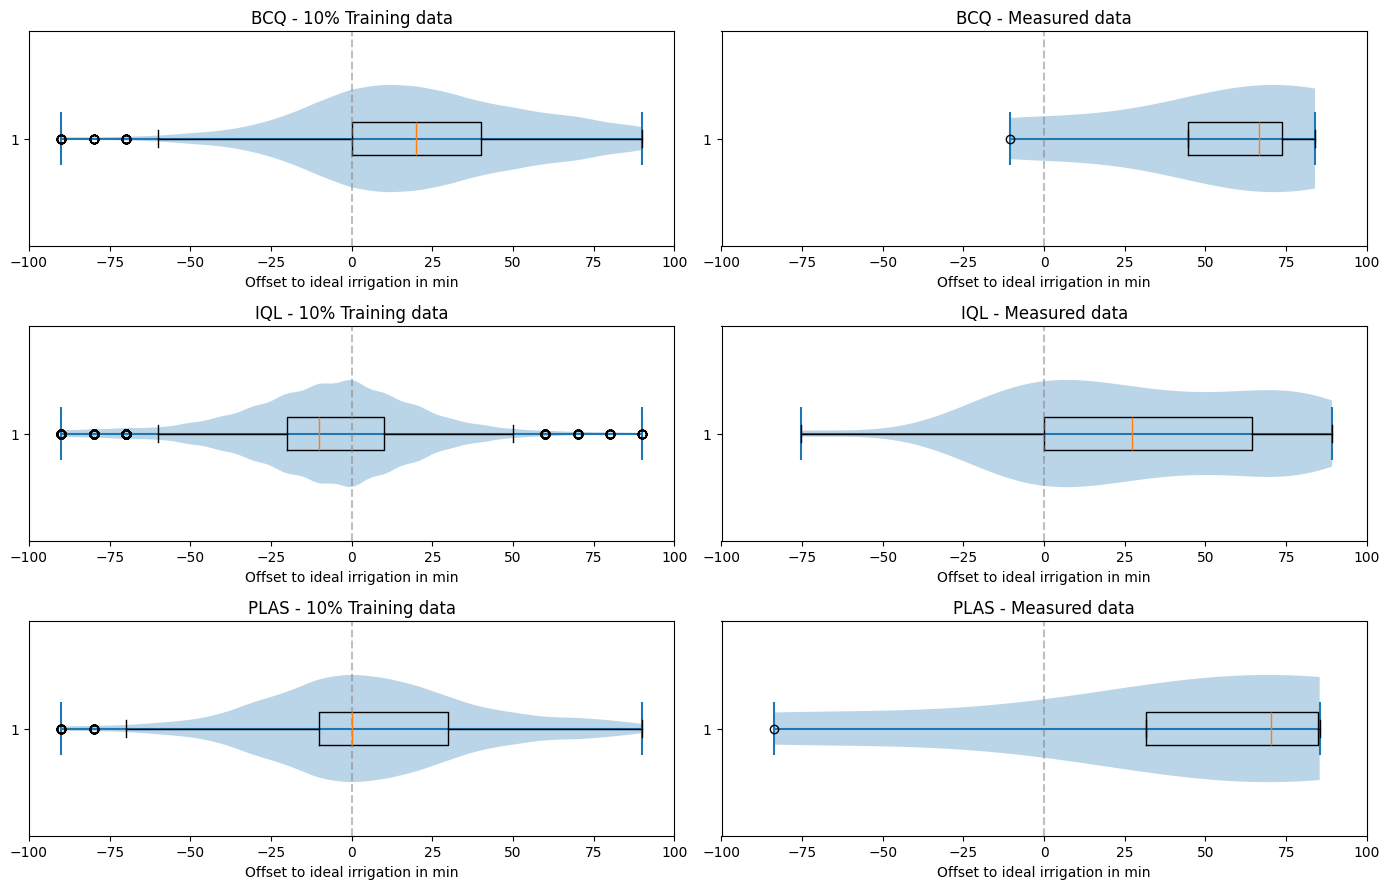

In [81]:
# === Violin-Plots: Simuliert | Gemessen (Seite an Seite) ===
n_algos = len(results_sim["algo_names"])
fig, axes = plt.subplots(n_algos, 2, figsize=(14, 3 * n_algos), squeeze=False)

# Gemeinsamer X-Achsen-Bereich
all_diffs = results_sim["soll_ist_diffs"] + results_meas["soll_ist_diffs"]
if all_diffs:
    x_min = min(min(d) for d in all_diffs if d) - 10
    x_max = max(max(d) for d in all_diffs if d) + 10
else:
    x_min, x_max = -100, 100

# Linke Spalte: Simulierte Daten
for i, (algo_name, soll_ist_diff) in enumerate(zip(results_sim["algo_names"], results_sim["soll_ist_diffs"])):
    ax = axes[i, 0]
    ax.violinplot(soll_ist_diff, vert=False)
    ax.boxplot(soll_ist_diff, vert=False)
    ax.set_title(f"{algo_name.split('_')[0]} - 10% Training data")
    ax.set_xlabel("Offset to ideal irrigation in min")
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(x_min, x_max)

# Rechte Spalte: Gemessene Daten
for i, (algo_name, soll_ist_diff) in enumerate(zip(results_meas["algo_names"], results_meas["soll_ist_diffs"])):
    ax = axes[i, 1]
    ax.violinplot(soll_ist_diff, vert=False)
    ax.boxplot(soll_ist_diff, vert=False)
    ax.set_title(f"{algo_name.split('_')[0]} - Measured data")
    ax.set_xlabel("Offset to ideal irrigation in min")
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

In [78]:
# === Vergleichstabellen ===

# Tabelle: Simulierte Daten
summary_df_sim = pd.DataFrame({
    "Algorithmus": results_sim["algo_names"],
    "Modell": results_sim["model_names"],
    "Error %": results_sim["error_rates"],
    "Within \u00b110min %": results_sim["within_10min"],
    "Within \u00b120min %": results_sim["within_20min"],
    "Within \u00b130min %": results_sim["within_30min"],
    "Median Offset (min)": results_sim["median_offset"],
    "Mean Offset (min)": results_sim["mean_offset"],
    "Std Offset (min)": results_sim["std_offset"],
    "Ideal Irrigations": results_sim["total_ideal"],
    "Model Triggers": results_sim["total_triggers"],
    "Missed": results_sim["missed"],
    "Extra Triggers": results_sim["extra"],
    "Errors (>\u00b190min)": results_sim["errors"],
})
summary_df_sim = summary_df_sim.sort_values("Error %").reset_index(drop=True)
print("===== Vergleichstabelle: SIMULIERT =====")
display(summary_df_sim)

# Tabelle: Gemessene Daten
summary_df_meas = pd.DataFrame({
    "Algorithmus": results_meas["algo_names"],
    "Modell": results_meas["model_names"],
    "Error %": results_meas["error_rates"],
    "Within \u00b110min %": results_meas["within_10min"],
    "Within \u00b120min %": results_meas["within_20min"],
    "Within \u00b130min %": results_meas["within_30min"],
    "Median Offset (min)": results_meas["median_offset"],
    "Mean Offset (min)": results_meas["mean_offset"],
    "Std Offset (min)": results_meas["std_offset"],
    "Ideal Irrigations": results_meas["total_ideal"],
    "Model Triggers": results_meas["total_triggers"],
    "Missed": results_meas["missed"],
    "Extra Triggers": results_meas["extra"],
    "Errors (>\u00b190min)": results_meas["errors"],
})
summary_df_meas = summary_df_meas.sort_values("Error %").reset_index(drop=True)
print("\n===== Vergleichstabelle: GEMESSEN =====")
display(summary_df_meas)

===== Vergleichstabelle: SIMULIERT =====


,Algorithmus,Modell,Error %,Within ±10min %,Within ±20min %,Within ±30min %,Median Offset (min),Mean Offset (min),Std Offset (min),Ideal Irrigations,Model Triggers,Missed,Extra Triggers,Errors (>±90min)
0,IQL_20260214233207,IQL_20260214233207/model_500000.d3,12.92,39.32,57.85,69.29,-10.0,-7.20,28.93,9654,13010,442,3798,805
1,BCQ_20260215032348,BCQ_20260215032348/model_500000.d3,41.08,18.97,29.13,37.11,20.0,20.79,33.81,9654,7280,2556,182,1410
2,PLAS_20260215203046,PLAS_20260215203046/model_500000.d3,47.31,20.49,30.82,38.53,0.0,6.20,33.55,9654,6121,3799,266,768



===== Vergleichstabelle: GEMESSEN =====


,Algorithmus,Modell,Error %,Within ±10min %,Within ±20min %,Within ±30min %,Median Offset (min),Mean Offset (min),Std Offset (min),Ideal Irrigations,Model Triggers,Missed,Extra Triggers,Errors (>±90min)
0,IQL_20260214233207,IQL_20260214233207/model_500000.d3,89.91,1.1,3.29,4.82,27.22,30.66,38.53,456,184,288,16,122
1,PLAS_20260215203046,PLAS_20260215203046/model_500000.d3,98.90,0.0,0.00,0.00,70.43,37.64,63.85,456,51,405,0,46
2,BCQ_20260215032348,BCQ_20260215032348/model_500000.d3,99.12,0.0,0.22,0.22,66.64,51.69,36.67,456,57,399,0,53


c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

  -> Selected: BCQ_20260215032348/model_500000.d3
  -> Selected: IQL_20260214233207/model_500000.d3
  -> Selected: PLAS_20260215203046/model_500000.d3
Geladene Modelle: ['BCQ', 'IQL', 'PLAS']


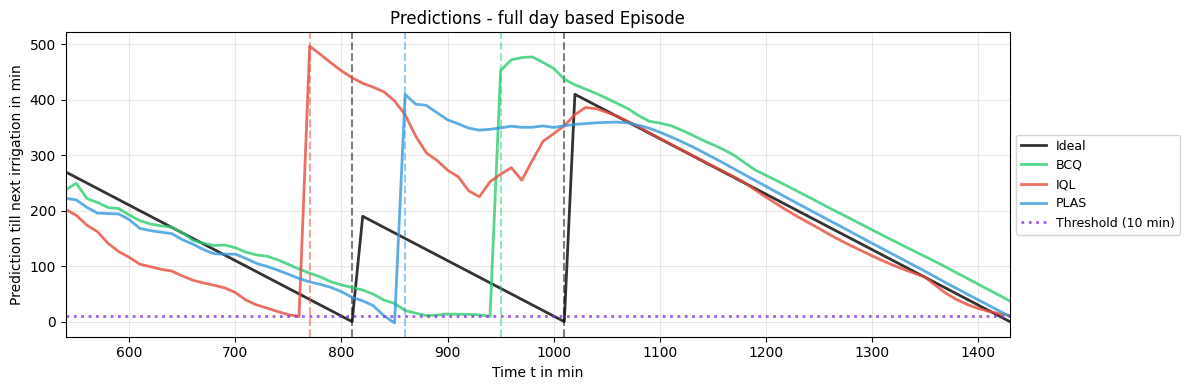

In [79]:
# === Beispiel-Plots: Einzelne Tages-Episoden mit allen Modellen ===

def plot_day_episode_with_models(episode, models_dict, episode_name="Episode"):
    """
    Plottet eine Tages-Episode mit Modell-Vorhersagen und idealen Bewässerungszeitpunkten.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 4))
    
    abstimes = [sample[ABSTIME_IDX] for sample in episode]
    time_to_irri = [sample[TIMETOIRRI_IDX] for sample in episode]
    
    # Ideale Bewässerungszeitpunkte
    ideal_times = [sample[ABSTIME_IDX] for sample in episode if sample[TIMETOIRRI_IDX] <= 0]
    
    # Ground Truth Linie
    ax1.plot(abstimes, time_to_irri, label='Ideal', color='black', linewidth=2, alpha=0.8)
    
    # Ideale Bewässerungszeitpunkte markieren
    for it in ideal_times[:-1]: # Letzten Trigger (Ende der Episode) nicht markieren
        ax1.axvline(x=it, color='black', linestyle='--', alpha=0.5)
    
    # Farben für Algorithmen
    colors = {'BCQ': '#2ecc71', 'PLAS': '#3498db', 'IQL': '#e74c3c', 'CQL': '#f39c12'}
    
    for algo_name, model in models_dict.items():
        color = colors.get(algo_name.upper(), '#999999')
        predictions, trigger_abstimes = simulate_day_episode(model, episode)
        
        ax1.plot(abstimes, predictions, label=algo_name, color=color, linewidth=2, alpha=0.8)
        
        for tt in trigger_abstimes:
            ax1.axvline(x=tt, color=color, linestyle='--', alpha=0.5)
    
    # Threshold-Linie
    ax1.axhline(y=10, color='#8a34db', linestyle=':', alpha=0.8, linewidth=2, label='Threshold (10 min)')
    
    ax1.set_xlabel('Time t in min')
    ax1.set_ylabel('Prediction till next irrigation in min')
    ax1.set_title(f'Predictions - full day based Episode')
    ax1.legend(fontsize=9, loc='center left', bbox_to_anchor=(1, 0.5))
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('linear')
    ax1.set_xlim(540, 1430)
    
    plt.tight_layout()
    plt.show()

# Lade alle Modelle
all_models = {}
if os.path.exists(base_dir):
    for algorithm_name in sorted(os.listdir(base_dir)):
        algorithm_path = os.path.join(base_dir, algorithm_name)
        if not os.path.isdir(algorithm_path):
            continue
        models = load_models_from_training(algorithm_path)
        for model_name, model in models:
            all_models[algorithm_name.split('_')[0]] = model

print(f"Geladene Modelle: {list(all_models.keys())}")

# ===== Manuell Episoden-Pfade angeben =====
episode_paths = [
    "../data/episFormula/testDayTEst/112_GRO-2023-8-2-Epi0.csv",
]

# Episoden laden und mit ALLEN Modellen plotten
for ep_path in episode_paths:
    if not os.path.exists(ep_path):
        print(f"Datei nicht gefunden: {ep_path}")
        continue
    with open(ep_path, "r", newline="") as file:
        reader = csv.reader(file)
        header = next(reader)
        episode = [[float(v) for v in row] for row in reader]
    ep_name = os.path.basename(ep_path)
    plot_day_episode_with_models(episode, all_models, ep_name)

In [80]:
from pathlib import Path
import random
import shutil
import math

source = Path("../data/episFormula/7.3 correct drain")   # Quellordner
target = Path("../data/episFormula/testDay")            # Zielordner
percent = 0.10                               # 10%

# Zielordner anlegen (falls nicht existiert)
target.mkdir(exist_ok=True)

# Alle Dateien im Quellordner holen
files = [f for f in source.iterdir() if f.is_file()]

# Anzahl berechnen
n_select = max(1, math.floor(len(files) * percent))

# Zufällige Auswahl
selected = random.sample(files, n_select)

# Kopieren
for f in selected:
    shutil.copy2(f, target / f.name)

print(f"Gefundene Dateien: {len(files)}")
print(f"Ausgewählt: {n_select}")
print("Fertig!")

Gefundene Dateien: 11424
Ausgewählt: 1142
Fertig!
